# Addestriamo un XGBoost

In [1]:
import numpy as np
import pandas as pd
import os
import requests
import zipfile
import io
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

def load_bike_sharing_data():
    """
    Scarica, decomprime e carica il dataset delle biciclette condivise.
    """
    print("Step 1: Preparazione dataset")
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip"

    if not os.path.exists('data'):
        os.makedirs('data')

    csv_path = 'data/hour.csv'

    if not os.path.exists(csv_path):
        print("   - Downloading dataset...")
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
                zip_ref.extractall('data')
            print("   - Dataset extracted successfully")
        else:
            raise Exception(f"Failed to download dataset. Status code: {response.status_code}")

    print("   - Loading dataset...")
    df = pd.read_csv(csv_path)

    features = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
               'workingday', 'weathersit', 'temp', 'atemp',
               'hum', 'windspeed']

    X = df[features]
    y = df['cnt']

    print(f"   - Dataset loaded. Shape: {X.shape}")

    return X, y, features

def train_xgboost_model(X, y, features):
    """
    Addestra un modello XGBoost per la previsione del bike sharing.
    Include preprocessing, training, cross-validation e valutazione.
    """
    # Dividiamo il dataset in training e test set
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Creiamo una pipeline con preprocessing e modello
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgboost', xgb.XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Addestriamo il modello
    print("Training del modello...")
    pipeline.fit(X_train, y_train)

    # Cross-validation sul training set
    print("\nCross-validation scores:")
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    print(f"RMSE CV scores: {-cv_scores}")
    print(f"Media RMSE CV: {-cv_scores.mean():.2f} (±{cv_scores.std()*2:.2f})")

    # Valutazione sul test set
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("\nValutazione sul test set:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.3f}")

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features,
        'importance': pipeline.named_steps['xgboost'].feature_importances_
    })
    feature_importance = feature_importance.sort_values('importance', ascending=False)

    print("\nFeature Importance:")
    print(feature_importance)

    return pipeline

# Esempio di utilizzo
if __name__ == "__main__":
    X, y, features = load_bike_sharing_data()
    model = train_xgboost_model(X, y, features)

Step 1: Preparazione dataset
   - Downloading dataset...
   - Dataset extracted successfully
   - Loading dataset...
   - Dataset loaded. Shape: (17379, 12)
Training del modello...

Cross-validation scores:
RMSE CV scores: [44.85935312 48.14560214 48.20118594 46.72876826 46.10100522]
Media RMSE CV: 46.81 (±2.54)

Valutazione sul test set:
RMSE: 44.72
R2 Score: 0.937

Feature Importance:
       feature  importance
3           hr    0.232500
1           yr    0.188196
6   workingday    0.156232
8         temp    0.133198
9        atemp    0.087516
0       season    0.085011
7   weathersit    0.052407
10         hum    0.022243
2         mnth    0.018287
5      weekday    0.012198
4      holiday    0.008101
11   windspeed    0.004111


# Analizziamo l'XGBoost

Calcolando SHAP values...


<Figure size 640x480 with 0 Axes>

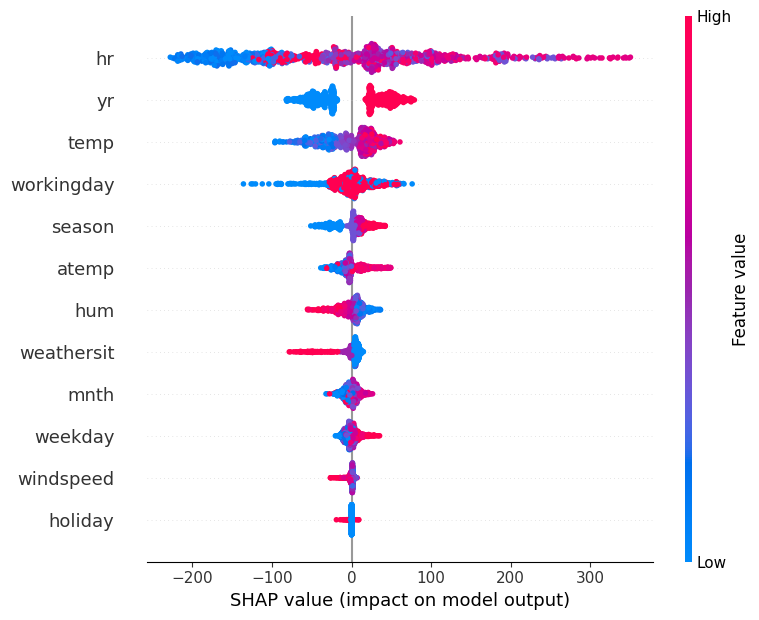


Analisi dettagliata delle top 3 feature:
----------------------------------------

Analizzando: hr


<Figure size 1200x600 with 0 Axes>

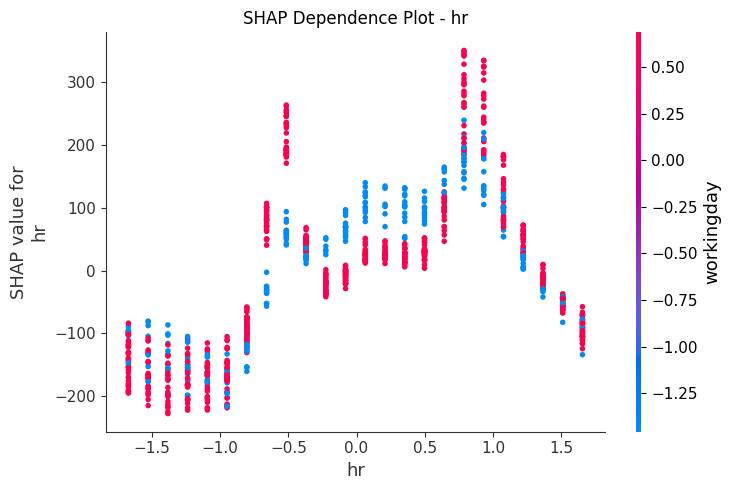

<Figure size 1200x600 with 0 Axes>

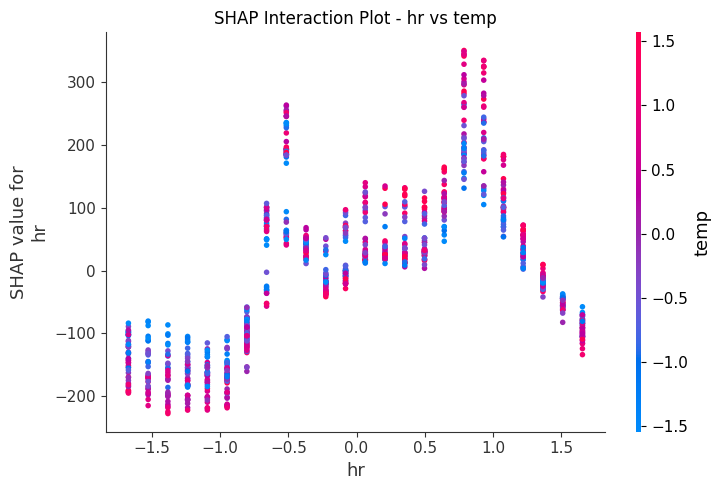


Analizzando: yr


<Figure size 1200x600 with 0 Axes>

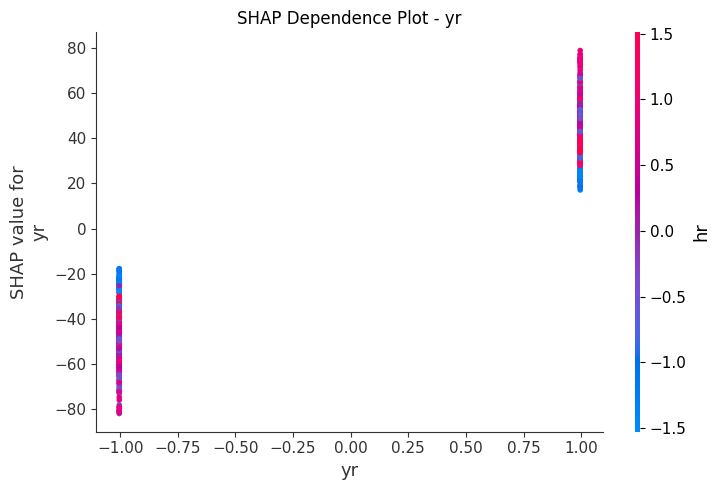

<Figure size 1200x600 with 0 Axes>

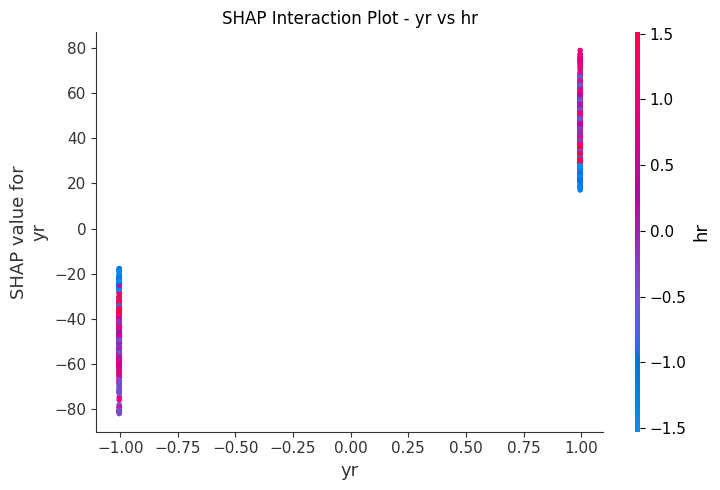


Analizzando: temp


<Figure size 1200x600 with 0 Axes>

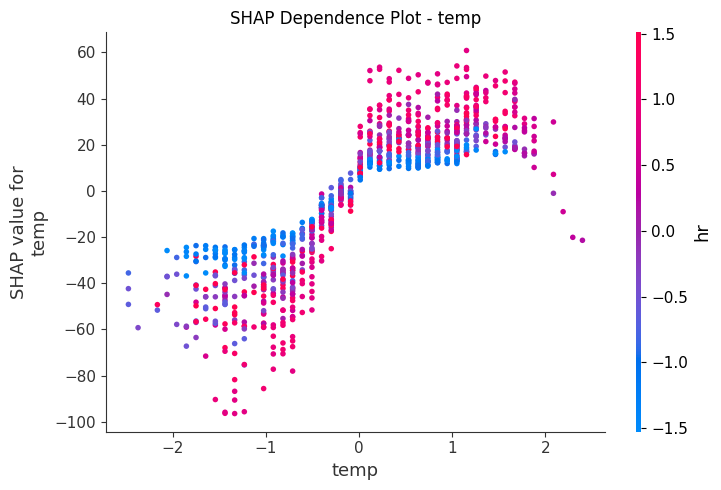

<Figure size 1200x600 with 0 Axes>

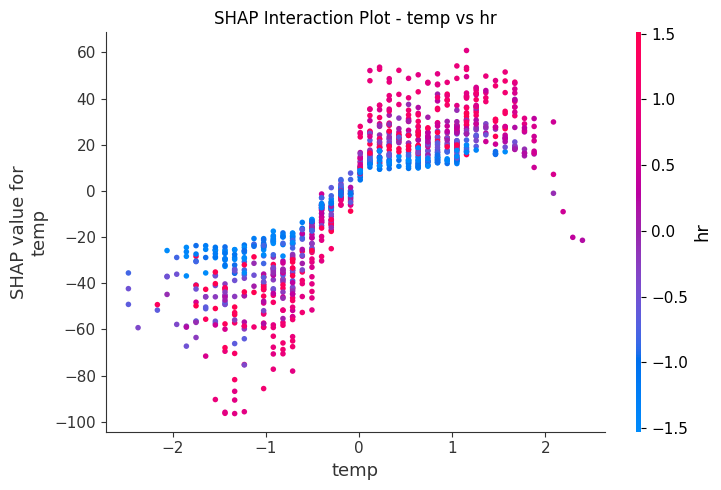

In [2]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
import pandas as pd

def get_model_from_pipeline(model):
    """
    Estrae il modello XGBoost dalla pipeline se necessario
    """
    if isinstance(model, Pipeline):
        # Assumiamo che il modello XGBoost sia l'ultimo step della pipeline
        return model.named_steps['xgboost']
    return model

def analyze_model(model, X, features):
    """
    Analizza il modello usando SHAP values
    """
    # Estraiamo il modello dalla pipeline se necessario
    tree_model = get_model_from_pipeline(model)

    # Se abbiamo una pipeline, dobbiamo trasformare i dati
    if isinstance(model, Pipeline):
        # Prendiamo tutti gli step della pipeline tranne l'ultimo (il modello)
        preprocessing_steps = Pipeline(model.steps[:-1])
        X_transformed = preprocessing_steps.transform(X)
        X_for_analysis = pd.DataFrame(X_transformed, columns=features)
    else:
        X_for_analysis = X

    # Calcoliamo i SHAP values
    print("Calcolando SHAP values...")
    explainer = shap.TreeExplainer(tree_model)
    # Prendiamo un campione di 1000 osservazioni per velocizzare l'analisi
    X_sample = X_for_analysis.sample(n=1000, random_state=42)
    shap_values = explainer.shap_values(X_sample)

    plt.clf()  # Puliamo la figura corrente
    plt.figure(figsize=(12, 6))
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=features,
        show=False,
    )
    plt.tight_layout()
    plt.show()


    # Troviamo le feature più importanti
    feature_importance = np.abs(shap_values).mean(0)
    top_features_idx = np.argsort(-feature_importance)[:3]
    top_features = [features[i] for i in top_features_idx]

    print("\nAnalisi dettagliata delle top 3 feature:")
    print("----------------------------------------")
    for feature in top_features:
        print(f"\nAnalizzando: {feature}")

        # SHAP Dependence plot
        plt.figure(figsize=(12, 6))
        shap.dependence_plot(
            features.index(feature),
            shap_values,
            X_sample,
            feature_names=features,
            show=False
        )
        plt.title(f"SHAP Dependence Plot - {feature}")
        plt.tight_layout()
        plt.show()

        # SHAP Interaction plot
        plt.figure(figsize=(12, 6))
        interaction_feature = top_features[0] if feature != top_features[0] else top_features[2]
        shap.dependence_plot(
            features.index(feature),
            shap_values,
            X_sample,
            feature_names=features,
            interaction_index=features.index(interaction_feature),
            show=False
        )
        plt.title(f"SHAP Interaction Plot - {feature} vs {interaction_feature}")
        plt.tight_layout()
        plt.show()

# Per utilizzarlo:
analyze_model(model, X, features)

# Uso avanzato Troviamo il Time Shift

Training del classificatore...


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [18:33:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Valutazione del modello:
Accuracy: 0.6300

Report di classificazione:
              precision    recall  f1-score   support

        2011       0.65      0.56      0.60      1722
        2012       0.62      0.70      0.66      1754

    accuracy                           0.63      3476
   macro avg       0.63      0.63      0.63      3476
weighted avg       0.63      0.63      0.63      3476


Calcolando SHAP values...


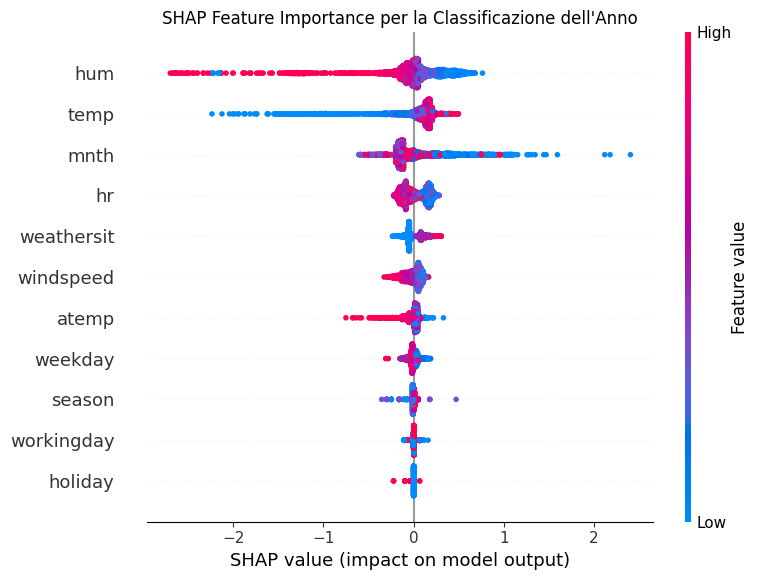

In [3]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

def create_classification_dataset(X, features):
    """
    Prepara il dataset per la classificazione dell'anno
    """
    # Estraiamo la feature target (yr)
    y = X['yr'].astype(int)

    # Rimuoviamo yr dalle feature
    features_for_classification = [f for f in features if f != 'yr']
    X_class = X[features_for_classification]

    return X_class, y, features_for_classification

def train_year_classifier(X, features):
    """
    Addestra un classificatore XGBoost per predire l'anno
    """
    # Prepariamo il dataset
    X_class, y, features_class = create_classification_dataset(X, features)

    # Split train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_class, y, test_size=0.2, random_state=42
    )

    # Creiamo la pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgboost', xgb.XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ))
    ])

    # Addestriamo il modello
    print("Training del classificatore...")
    pipeline.fit(X_train, y_train)

    # Valutiamo il modello
    y_pred = pipeline.predict(X_test)

    print("\nValutazione del modello:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nReport di classificazione:")
    print(classification_report(y_test, y_pred, target_names=['2011', '2012']))

    # SHAP Analysis
    print("\nCalcolando SHAP values...")
    # Estraiamo il modello dalla pipeline
    model = pipeline.named_steps['xgboost']
    # Trasformiamo i dati
    X_transformed = pipeline.named_steps['scaler'].transform(X_test)
    X_test_transformed = pd.DataFrame(X_transformed, columns=features_class)

    # Calcoliamo i valori SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_transformed)

    # Plot SHAP summary
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=features_class,
        show=False
    )
    plt.title("SHAP Feature Importance per la Classificazione dell'Anno")
    plt.tight_layout()
    plt.show()

    return pipeline, features_class

pipeline, features_class = train_year_classifier(X, features)


# A cosa può servire?
* Trovi le feature che portano più facilmente overfit
* Rendi il modello più stabile
* Un Evviva per XAI!